In [ ]:
!pip install imblearn

In [143]:
import warnings
warnings.filterwarnings('ignore')

In [144]:
# Standard libraries
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn modules
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeCV, LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, silhouette_score, f1_score)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Category Encoders
from category_encoders import BinaryEncoder

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, GlobalMaxPooling1D, Flatten, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Suppress warnings



In [145]:
df_applications = pd.read_csv('./data/cleaned_data/applications.csv')
df_voyage_schedule = pd.read_csv('./data/cleaned_data/voyage_schedule.csv')

In [146]:
# Examine the shape and data types of both DataFrames
print("df_applications shape:", df_applications.shape)
print("df_applications data types:\n", df_applications.dtypes)
print("\ndf_voyage_schedule shape:", df_voyage_schedule.shape)
print("df_voyage_schedule data types:\n", df_voyage_schedule.dtypes)

# Inspect the 'voyage(from voyage signup)' column in df_applications
print("\nUnique values in voyage_from_voyage_signups':", df_applications['voyage_from_voyage_signups'].unique())
print("Value counts for 'voyage_from_voyage_signups)':\n", df_applications['voyage_from_voyage_signups'].value_counts())
print("Missing values in 'voyage_from_voyage_signups':", df_applications['voyage_from_voyage_signups'].isnull().sum())

# Identify the relevant columns in df_voyage_schedule
print("\nRelevant columns in df_voyage_schedule (Voyage numbers and dates): 'Name', 'Start Date', 'End Date'")

# Analyze the relationship between the voyage numbers in both DataFrames
common_voyages = set(df_applications['voyage_from_voyage_signups'].dropna()).intersection(set(df_voyage_schedule['Name']))
print("\nCommon voyage numbers between df_applications and df_voyage_schedule:", common_voyages)

df_applications shape: (10600, 27)
df_applications data types:
 unique_id                      object
timestamp                      object
subscription_status            object
subscription_status_dt         object
voyage_role                    object
gender                         object
country_code                   object
goal                           object
source                         object
source_other                   object
country_name_from_country      object
voyage_from_voyage_signups     object
application_age_in_days       float64
application_day_of_week        object
day_of_week_no                float64
no_voyages_started            float64
application_date               object
application_year              float64
updated_voyage_number          object
updated_voyage_start_date      object
application_month             float64
application_week              float64
subscription_status_year      float64
subscription_status_month     float64
subscription_status_week

In [147]:
# Analyze the 'Voyage (from Voyage Signups)' column for inconsistencies and patterns
# Check for multiple voyage numbers separated by commas
df_applications['voyage_from_voyage_signups'].str.contains(',').sum()

# Analyze the frequency of 'V??' and its potential meaning
print("Frequency of 'V??':", df_applications['voyage_from_voyage_signups'].str.contains('V\?\?').sum())

# Further exploration:
# Analyze the relationship between the voyage numbers and the 'Application Date' column
# Check if there are any specific voyage numbers associated with missing values
# Analyze the 'Voyage Role' and 'Goal' columns in relation to the voyage numbers

Frequency of 'V??': 146


In [148]:
# Analyze the relationship between the voyage numbers in both DataFrames
# Check if there are any common voyage numbers, and if the voyage numbers in df_applications match the voyage numbers in df_voyage_schedule
common_voyages = set(df_applications['voyage_from_voyage_signups'].dropna()).intersection(set(df_voyage_schedule['Name']))
print("Common voyage numbers between df_applications and df_voyage_schedule:", common_voyages)

# Explore the potential meaning of 'V??'
# Check if it's associated with a specific application date or other attributes
df_v_question_mark = df_applications[df_applications['voyage_from_voyage_signups'].str.contains('V\?\?', na=False)]
print("\nRows with 'V??':\n", df_v_question_mark.head())

# Check if 'V??' is related to the application date
print("\nApplication dates associated with 'V??':\n", df_v_question_mark['application_date'].value_counts())

Common voyage numbers between df_applications and df_voyage_schedule: {'V46', 'V51', 'V39', 'V42', 'V45', 'V36', 'V35', 'V54', 'V34', 'V49', 'V38', 'V48', 'V47', 'V55', 'V52', 'V41', 'V40', 'V33', 'V43', 'V37', 'V32', 'V53', 'V50', 'V44'}

Rows with 'V??':
                             unique_id         timestamp subscription_status  \
24   7be16909aa5092c16b8aca8e2b670969   2025-02-26 1:49              Active   
27   2edcefff8314a00296bf4adc1aa25ed0  2025-02-25 15:57              Active   
30   9f4e32681a0ab7d9e534a276d13c8c65  2025-02-25 13:48              Active   
55   0b79c89ebb33b3b73e8818a7340a516b  2025-02-23 14:53              Active   
119  020d590f46116b3351b0624996b4ac43  2025-02-13 21:37              Active   

    subscription_status_dt   voyage_role  gender country_code  \
24              2025-02-26     Developer  FEMALE           IN   
27              2025-02-25     Developer  FEMALE           BR   
30              2025-02-25     Developer    MALE           US   
55     

In [149]:
df_expanded_applications = pd.DataFrame()

for index, row in df_applications.iterrows():
  voyage_str = row['voyage_from_voyage_signups']
  if isinstance(voyage_str, str) and ',' in voyage_str:
    voyages = [v.strip() for v in voyage_str.split(',')]
    for voyage in voyages:
      new_row = row.copy()
      new_row['voyage_from_voyage_signups'] = voyage
      df_expanded_applications = pd.concat([df_expanded_applications, pd.DataFrame([new_row])], ignore_index=True)
  else:
    df_expanded_applications = pd.concat([df_expanded_applications, pd.DataFrame([row])], ignore_index=True)

In [150]:
voyage_date_dict = {}
for index, row in df_voyage_schedule.iterrows():
  voyage_number = row['Name']
  start_date = row['Start Date']
  if pd.notna(start_date):
    voyage_date_dict[voyage_number] = start_date

In [151]:
# Convert date fields to datetime
df_expanded_applications['application_date'] = pd.to_datetime(df_applications['application_date'], errors='coerce')
df_voyage_schedule['Start Date'] = pd.to_datetime(df_voyage_schedule['Start Date'], errors='coerce')

# Prepare target columns
df_expanded_applications['updated_voyage_number'] = None
df_expanded_applications['updated_voyage_number'] = None

# Sort voyages by Start Date
df_voyage_schedule = df_voyage_schedule.sort_values('Start Date')

# Function to get the next voyage
def find_next_voyage(application_date):
    if pd.isna(application_date):
        return None, None
    future_voyages = df_voyage_schedule[df_voyage_schedule['Start Date'] > application_date]
    if future_voyages.empty:
        return None, None
    next_voyage = future_voyages.iloc[1]  # Pick the first available voyage
    return next_voyage['Name'], next_voyage['Start Date'] 

# Apply update for 'V??'
mask = df_expanded_applications['voyage_from_voyage_signups'] == 'V??'
for idx in df_expanded_applications[mask].index:
    app_date = df_expanded_applications.at[idx, 'application_date']
    name, start_date = find_next_voyage(app_date)
    df_expanded_applications.at[idx, 'updated_voyage_number'] = name
    df_expanded_applications.at[idx, 'updated_voyage_start_date'] = start_date

# Regex to match 'V##' where ## is numeric (2 or 3 digits)
regex_mask = df_expanded_applications['voyage_from_voyage_signups'].fillna('').str.match(r'^V\d{2,3}$')

# Apply update for 'V##'
for idx in df_expanded_applications[regex_mask].index:
    voyage_name = df_expanded_applications.at[idx, 'voyage_from_voyage_signups']
    voyage_row = df_voyage_schedule[df_voyage_schedule['Name'] == voyage_name]
    if not voyage_row.empty:
        df_expanded_applications.at[idx, 'updated_voyage_start_date'] = voyage_row.iloc[0]['Start Date']
        df_expanded_applications.at[idx, 'updated_voyage_number'] = voyage_name


In [152]:
df_expanded_applications['updated_voyage_number'].fillna('')
df_expanded_applications['updated_voyage_start_date'].fillna('')

0         
1         
2         
3         
4         
        ..
10595     
10596     
10597     
10598     
10599     
Name: updated_voyage_start_date, Length: 10600, dtype: object

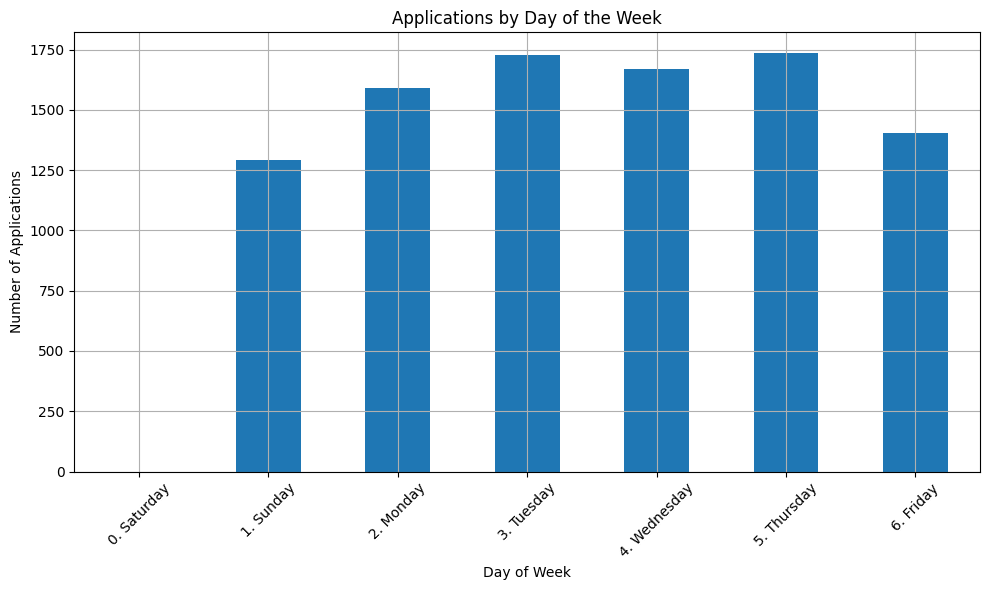

In [153]:
# Prepare data for weekly trends by 'Application Day-of-Week'
day_order = ['0. Saturday', '1. Sunday', '2. Monday', '3. Tuesday', '4. Wednesday', '5. Thursday', '6. Friday']

# Count number of applications per day of week
weekly_counts = df_expanded_applications['application_day_of_week'].value_counts().reindex(day_order)

# Plot
plt.figure(figsize=(10, 6))
weekly_counts.plot(kind='bar')
plt.title("Applications by Day of the Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Applications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

<Figure size 2000x1500 with 0 Axes>

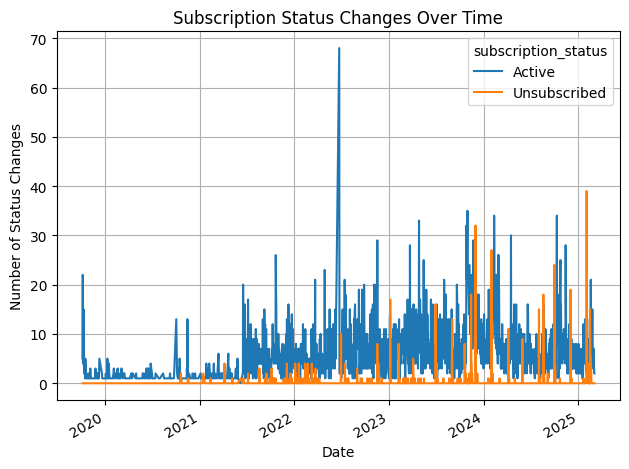

In [154]:
# Convert 'Subscription Status DT' to datetime
df_expanded_applications['subscription_status_dt'] = pd.to_datetime(df_expanded_applications['subscription_status_dt'], errors='coerce')

# Count subscription status changes over time
subscription_time_series = (
    df_expanded_applications.groupby(['subscription_status_dt', 'subscription_status'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Plot
plt.figure(figsize=(20, 15))
subscription_time_series.plot()
plt.title("Subscription Status Changes Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Status Changes")
plt.grid(True)
plt.tight_layout()
plt.show()

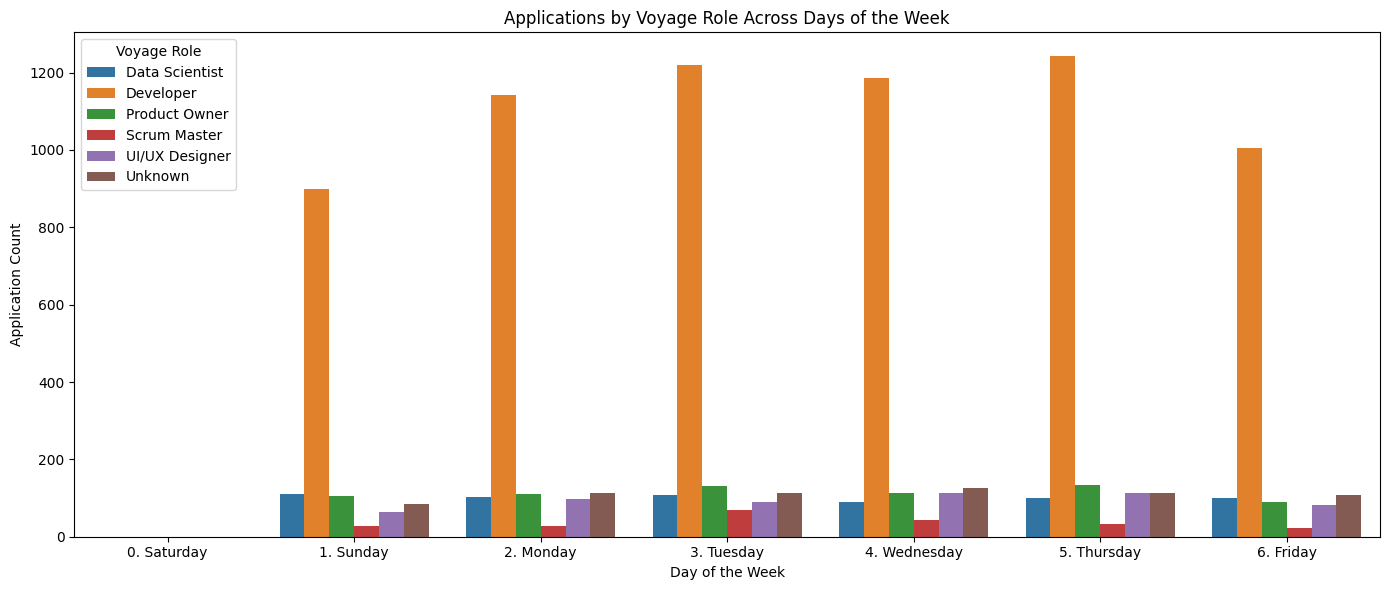

In [155]:
# Filter relevant columns
role_goal_df = df_expanded_applications[['voyage_role', 'goal', 'application_day_of_week']].dropna()

# Count of applications by Role and Day of Week
role_day_counts = (
    role_goal_df.groupby(['application_day_of_week', 'voyage_role'])
    .size()
    .reset_index(name='Count')
)

# Sort days
role_day_counts['application_day_of_week'] = pd.Categorical(
    role_day_counts['application_day_of_week'],
    categories=['0. Saturday', '1. Sunday', '2. Monday', '3. Tuesday', '4. Wednesday', '5. Thursday', '6. Friday'],
    ordered=True
)

# Plot
plt.figure(figsize=(14, 6))
sns.barplot(
    data=role_day_counts,
    x='application_day_of_week',
    y='Count',
    hue='voyage_role'
)
plt.title("Applications by Voyage Role Across Days of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Application Count")
plt.legend(title='Voyage Role')
plt.tight_layout()
plt.show()

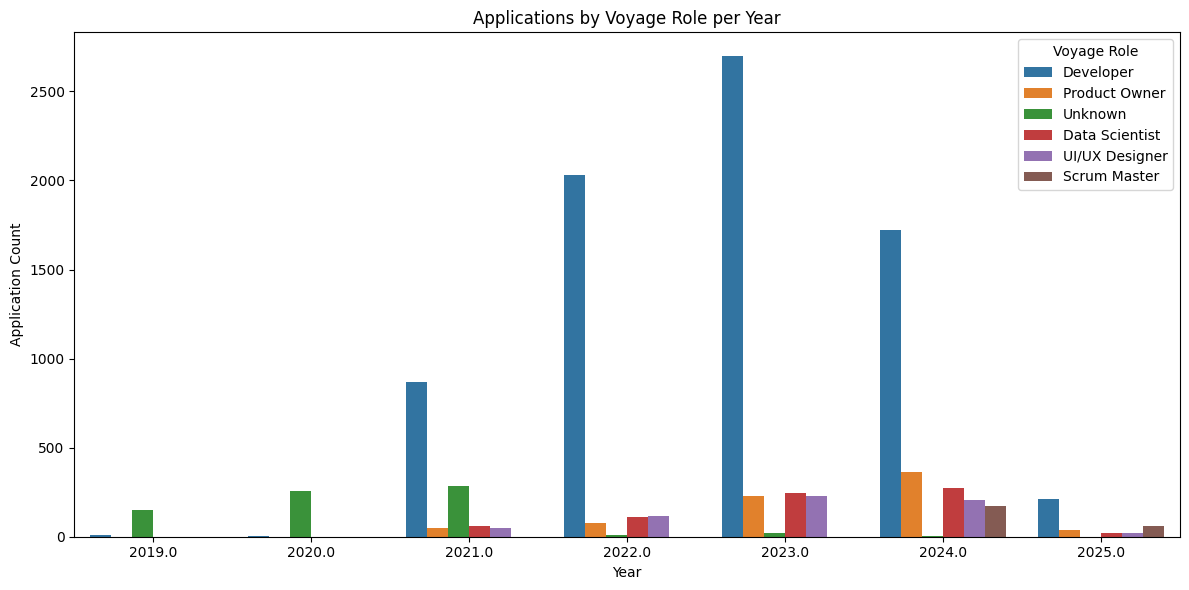

In [156]:
# Convert 'Timestamp' to datetime
df_expanded_applications['timestamp'] = pd.to_datetime(df_expanded_applications['timestamp'], errors='coerce')

# Extract year from timestamp
df_expanded_applications['application_year'] = df_expanded_applications['timestamp'].dt.year

# Group by year and Voyage Role
year_role_counts = (
    df_expanded_applications.groupby(['application_year', 'voyage_role'])
    .size()
    .reset_index(name='Count')
    .dropna()
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=year_role_counts,
    x='application_year',
    y='Count',
    hue='voyage_role'
)
plt.title("Applications by Voyage Role per Year")
plt.xlabel("Year")
plt.ylabel("Application Count")
plt.legend(title='Voyage Role')
plt.tight_layout()
plt.show()

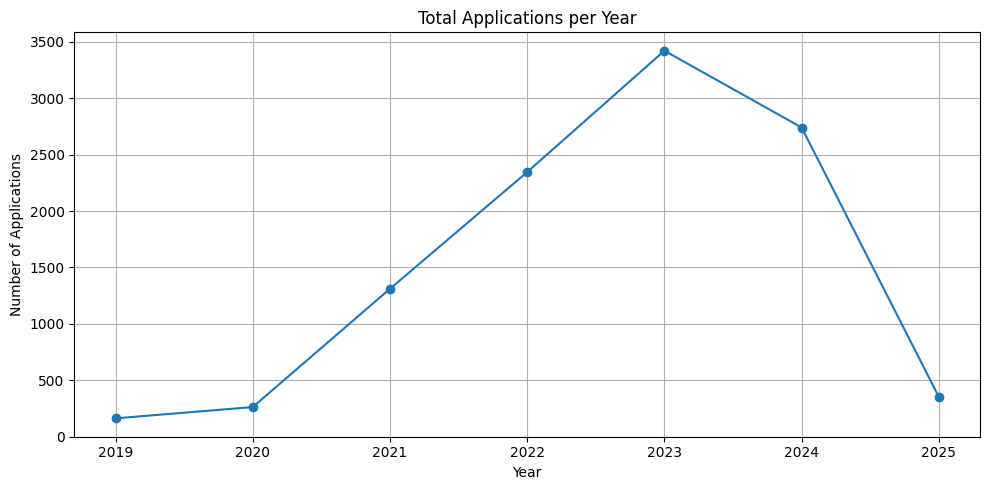

In [157]:
yearly_trend = df_expanded_applications['application_year'].value_counts().sort_index()

# Plot line trend
plt.figure(figsize=(10, 5))
plt.plot(yearly_trend.index, yearly_trend.values, marker='o')
plt.title("Total Applications per Year")
plt.xlabel("Year")
plt.ylabel("Number of Applications")
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

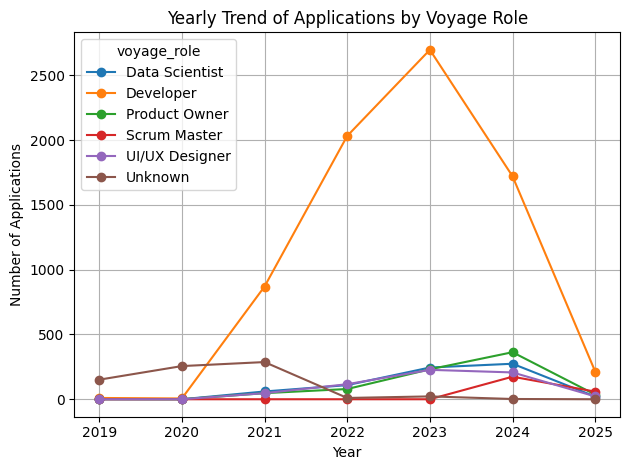

<Figure size 1400x600 with 0 Axes>

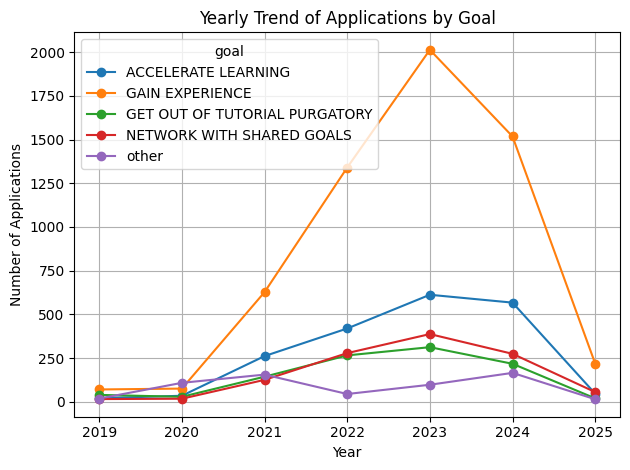

In [158]:
# Group by year and voyage role
yearly_role_trend = (
    df_expanded_applications.groupby(['application_year', 'voyage_role'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Group by year and goal
yearly_goal_trend = (
    df_expanded_applications.groupby(['application_year', 'goal'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Plot role trend
plt.figure(figsize=(12, 5))
yearly_role_trend.plot(marker='o')
plt.title("Yearly Trend of Applications by Voyage Role")
plt.xlabel("Year")
plt.ylabel("Number of Applications")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot goal trend
plt.figure(figsize=(14, 6))
yearly_goal_trend.plot(marker='o')
plt.title("Yearly Trend of Applications by Goal")
plt.xlabel("Year")
plt.ylabel("Number of Applications")
plt.grid(True)
plt.tight_layout()
plt.show()

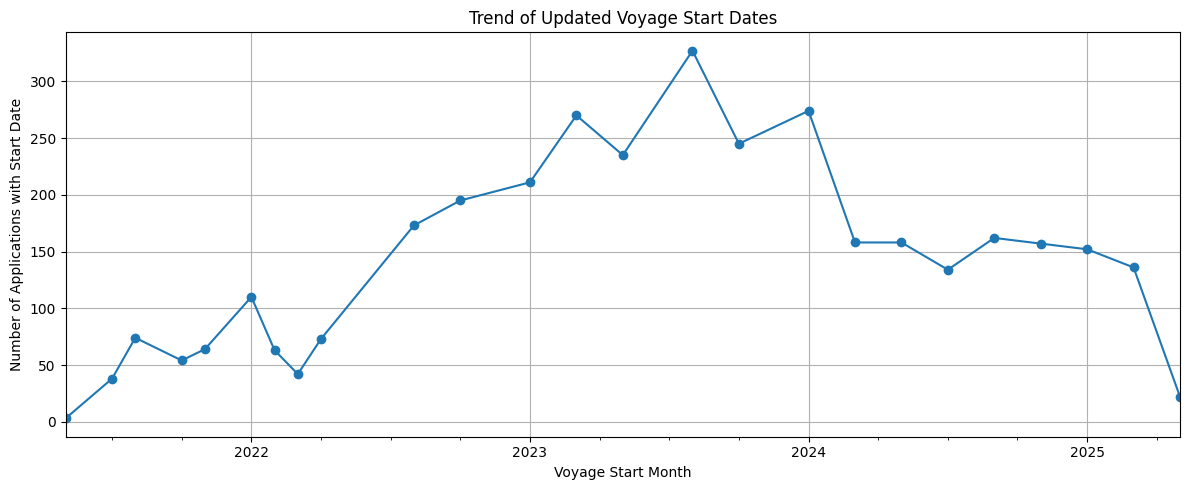

In [159]:
# Convert 'Updated Voyage Start Date' to datetime
df_expanded_applications['updated_voyage_start_date'] = pd.to_datetime(df_expanded_applications['updated_voyage_start_date'], errors='coerce')

# Drop rows with no start date
voyage_start_df = df_expanded_applications.dropna(subset=['updated_voyage_start_date'])

# Group by month-year for trend
voyage_start_df['voyage_start_month'] = voyage_start_df['updated_voyage_start_date'].dt.to_period('M')

# Count of voyages starting each month
voyage_start_trend = (
    voyage_start_df.groupby('voyage_start_month')
    .size()
    .sort_index()
)

# Plot
plt.figure(figsize=(12, 5))
voyage_start_trend.plot(marker='o')
plt.title("Trend of Updated Voyage Start Dates")
plt.xlabel("Voyage Start Month")
plt.ylabel("Number of Applications with Start Date")
# add a legend for goal and role 
plt.grid(True)
plt.tight_layout()
plt.show()

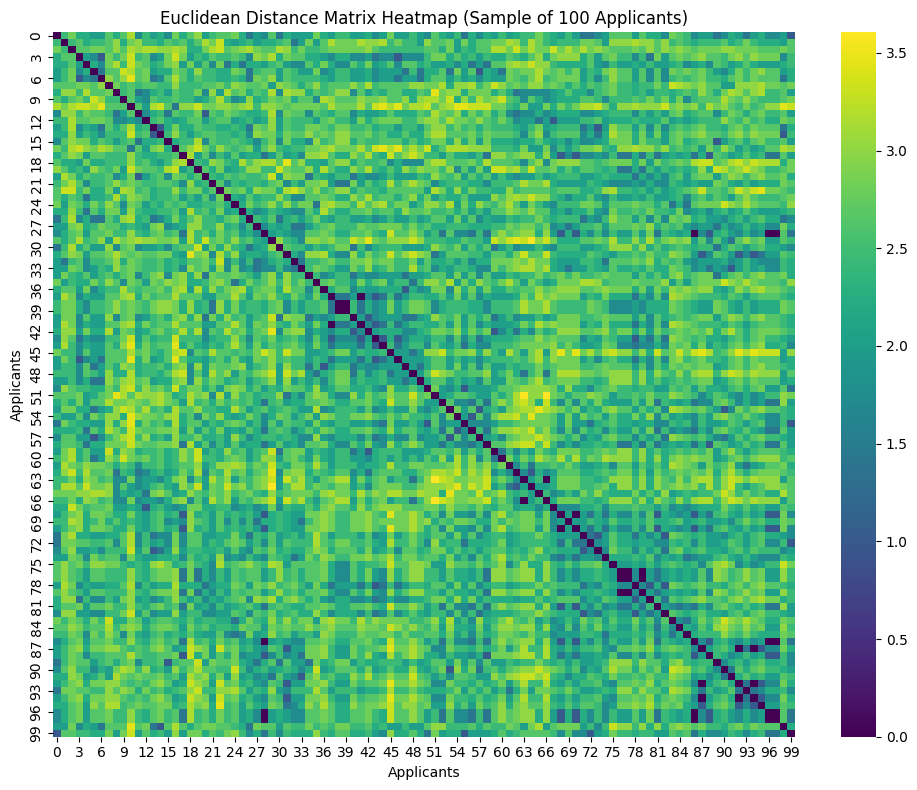

In [160]:
# Filter relevant features
features = [
    'voyage_role', 'gender', 'goal', 'source',
    'subscription_status', 'application_age_in_days', 'application_day_of_week' , 
]

X = df_expanded_applications[features]
y = df_expanded_applications['has_voyage']

# Preprocessing
categorical = ['voyage_role', 'gender', 'goal', 'source','subscription_status', 'application_day_of_week']
numerical = ['application_age_in_days']

preprocessor = ColumnTransformer([
    ('cat', BinaryEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numerical)
])

# Fit preprocessing on full dataset for clustering insight
X_processed = preprocessor.fit_transform(X)

# Compute distance matrix for clustering-based grouping
sample_size = 100
X_sample = X_processed[:sample_size].toarray() if hasattr(X_processed[:sample_size], 'toarray') else X_processed[:sample_size]
distance_matrix = distance.cdist(X_sample, X_sample, metric='euclidean')

# Heatmap of distance matrix
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, cmap='viridis')
plt.title("Euclidean Distance Matrix Heatmap (Sample of 100 Applicants)")
plt.xlabel("Applicants")
plt.ylabel("Applicants")
plt.tight_layout()
plt.show()


In [161]:
def plot_roc_curve(y_true, y_scores, title):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.2f})', color='blue')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

In [162]:
# Target column
target = "has_voyage"

# Drop columns that should not be used for prediction
cols_to_drop = [
    "unique_id", "timestamp", "subscription_status_dt",
    "updated_voyage_start_date", "application_date",
    "voyage_from_voyage_signups", "source_other"
]
original_df = df_expanded_applications.copy()  # Backup for external function use
df_expanded_applications = df_expanded_applications.drop(columns=cols_to_drop)

# Drop rows with missing target or fill missing features
X = df_expanded_applications.drop(columns=[target])
y = df_expanded_applications[target]

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["float64", "int64"]).columns.tolist()

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("binary", BinaryEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Full pipeline
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

# Split the data
X_intra, X_extra, y_intra, y_extra = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_intra, y_intra, test_size=0.2, random_state=42)

# Fit model
clf.fit(X_train, y_train)

# Predictions for Test 
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# Predictions for Extrapolation
y_pred_extra = clf.predict(X_extra)
y_prob_extra = clf.predict_proba(X_extra)[:, 1]



Confusion Matrix for Test set:
 [[1131    0]
 [   0  565]]

Classification Report for Test set:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1131
           1       1.00      1.00      1.00       565

    accuracy                           1.00      1696
   macro avg       1.00      1.00      1.00      1696
weighted avg       1.00      1.00      1.00      1696


ROC-AUC Score for Test set: 1.0


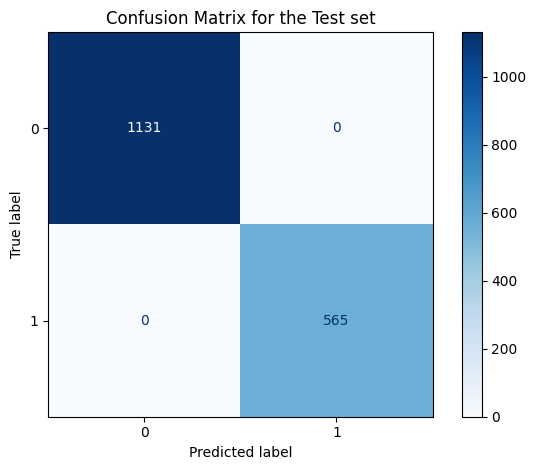

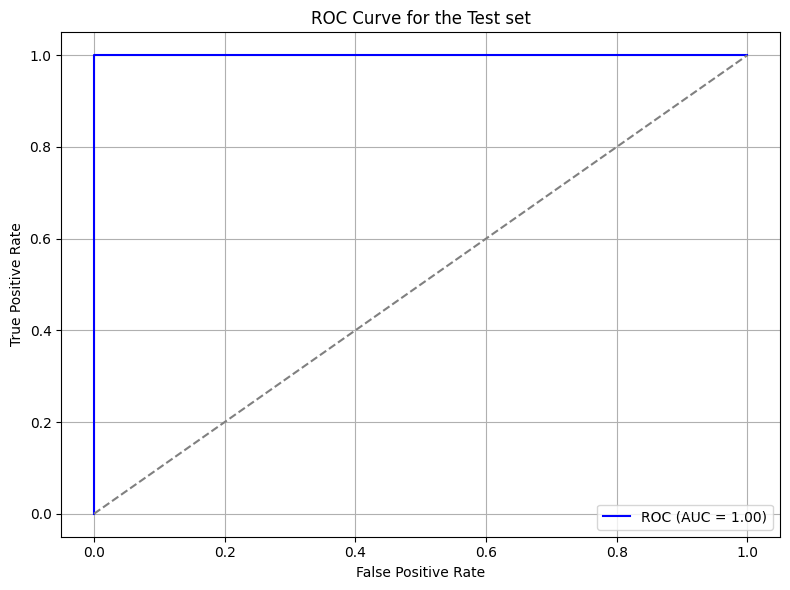

Confusion Matrix for Extrapolation set:
 [[1131    0]
 [   0  565]]

Classification Report for Extrapolation set:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1131
           1       1.00      1.00      1.00       565

    accuracy                           1.00      1696
   macro avg       1.00      1.00      1.00      1696
weighted avg       1.00      1.00      1.00      1696


ROC-AUC Score for Extrapolation set: 1.0


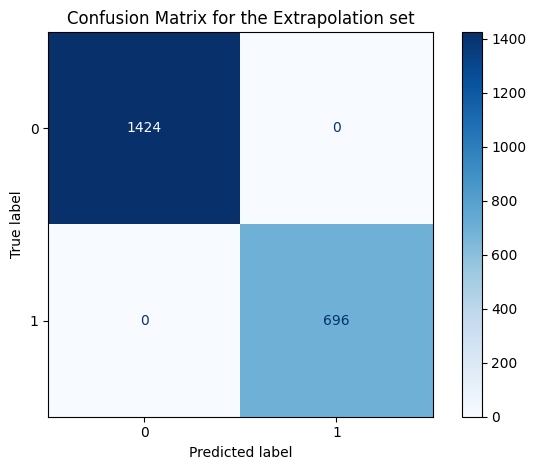

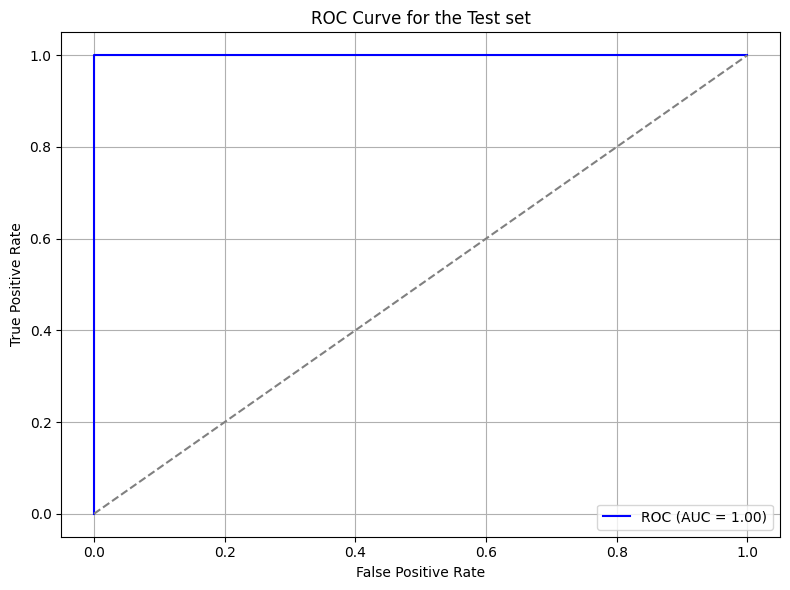

In [163]:

# Evaluation
print("Confusion Matrix for Test set:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report for Test set:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score for Test set:", roc_auc_score(y_test, y_prob))
plot_confusion(y_test, y_pred, "Confusion Matrix for the Test set")
plot_roc_curve(y_test, y_prob , "ROC Curve for the Test set")

# Evaluation for Extrapolation
print("Confusion Matrix for Extrapolation set:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report for Extrapolation set:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score for Extrapolation set:", roc_auc_score(y_test, y_prob))
plot_confusion(y_extra, y_pred_extra, "Confusion Matrix for the Extrapolation set")
plot_roc_curve(y_extra, y_prob_extra , "ROC Curve for the Test set")




Predicted number of participants by voyage and role:
    updated_voyage_start_date     voyage_role  predicted_participants
0                  2021-05-03       Developer                       1
1                  2021-05-03         Unknown                       1
2                  2021-05-31         Unknown                       1
3                  2021-07-19       Developer                       3
4                  2021-07-19   Product Owner                       1
..                        ...             ...                     ...
118                2025-05-05    Scrum Master                       5
115                2025-05-05  Data Scientist                       1
116                2025-05-05       Developer                      14
117                2025-05-05   Product Owner                       1
119                2025-05-05  UI/UX Designer                       1

[120 rows x 3 columns]


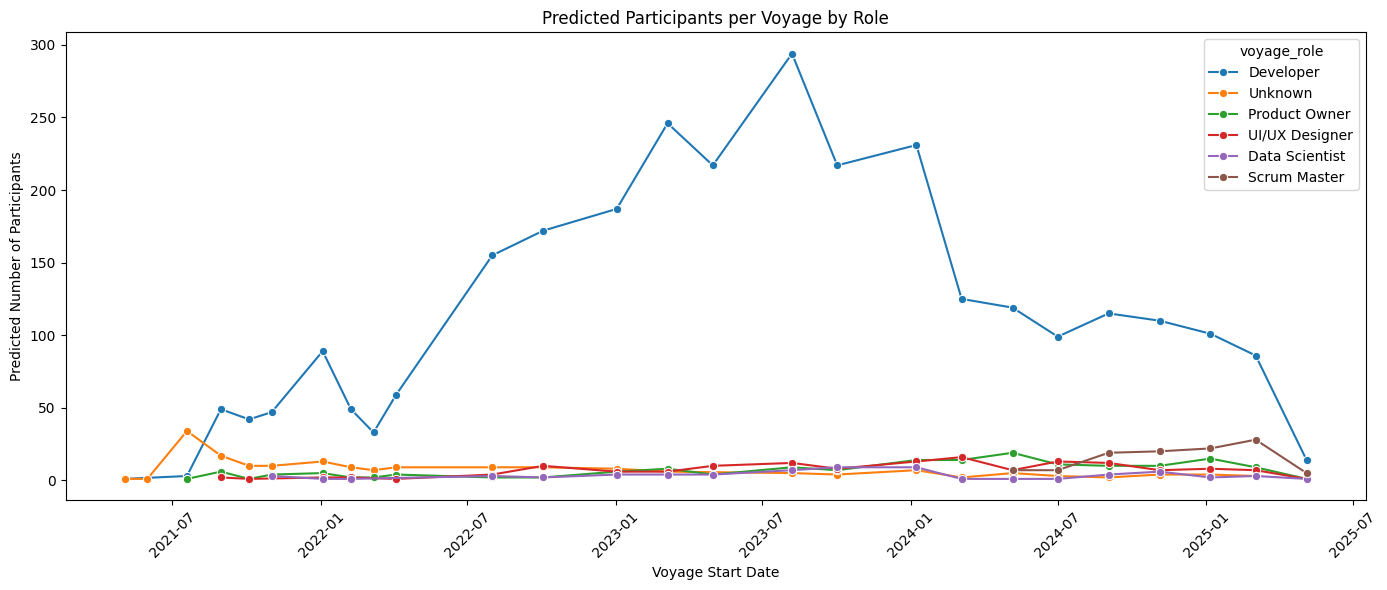

In [189]:
# Save voyage start date and role for group analysis
voyage_roles = original_df[["updated_voyage_start_date", "voyage_role"]].copy()

# Predict on full data
participation_predictions = clf.predict(X)

# Append predictions back for aggregation
df_results = voyage_roles.copy()
df_results["predicted_participation"] = participation_predictions

# Drop rows without voyage start date for forecasting
df_results = df_results.dropna(subset=["updated_voyage_start_date"])
df_results["updated_voyage_start_date"] = pd.to_datetime(df_results["updated_voyage_start_date"], errors='coerce')

# Filter for voyages up to end of 2025
df_results = df_results[df_results["updated_voyage_start_date"] <= pd.Timestamp("2025-12-31")]

# Group predictions by voyage and role
grouped_predictions = df_results.groupby(["updated_voyage_start_date", "voyage_role"])\
                                 .agg(predicted_participants=("predicted_participation", "sum"))\
                                 .reset_index()

# Show upcoming voyage participant forecasts
print("\nPredicted number of participants by voyage and role:")
print(grouped_predictions.sort_values("updated_voyage_start_date"))

# Plot predictions
plt.figure(figsize=(14, 6))
sns.lineplot(data=grouped_predictions, x="updated_voyage_start_date", y="predicted_participants", hue="voyage_role", marker="o")
plt.title("Predicted Participants per Voyage by Role")
plt.xlabel("Voyage Start Date")
plt.ylabel("Predicted Number of Participants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Synthetic predictions for future voyage months:
   voyage_month     voyage_role  predicted_participants
0       2025-10       Developer                      14
1       2025-10  Data Scientist                       6
2       2025-10    Scrum Master                      23
3       2025-10   Product Owner                       9
4       2025-10  UI/UX Designer                      13
5       2025-11       Developer                      21
6       2025-11  Data Scientist                       6
7       2025-11    Scrum Master                      19
8       2025-11   Product Owner                      11
9       2025-11  UI/UX Designer                       6
10      2025-12       Developer                      18
11      2025-12  Data Scientist                       6
12      2025-12    Scrum Master                      21
13      2025-12   Product Owner                       9
14      2025-12  UI/UX Designer                      15


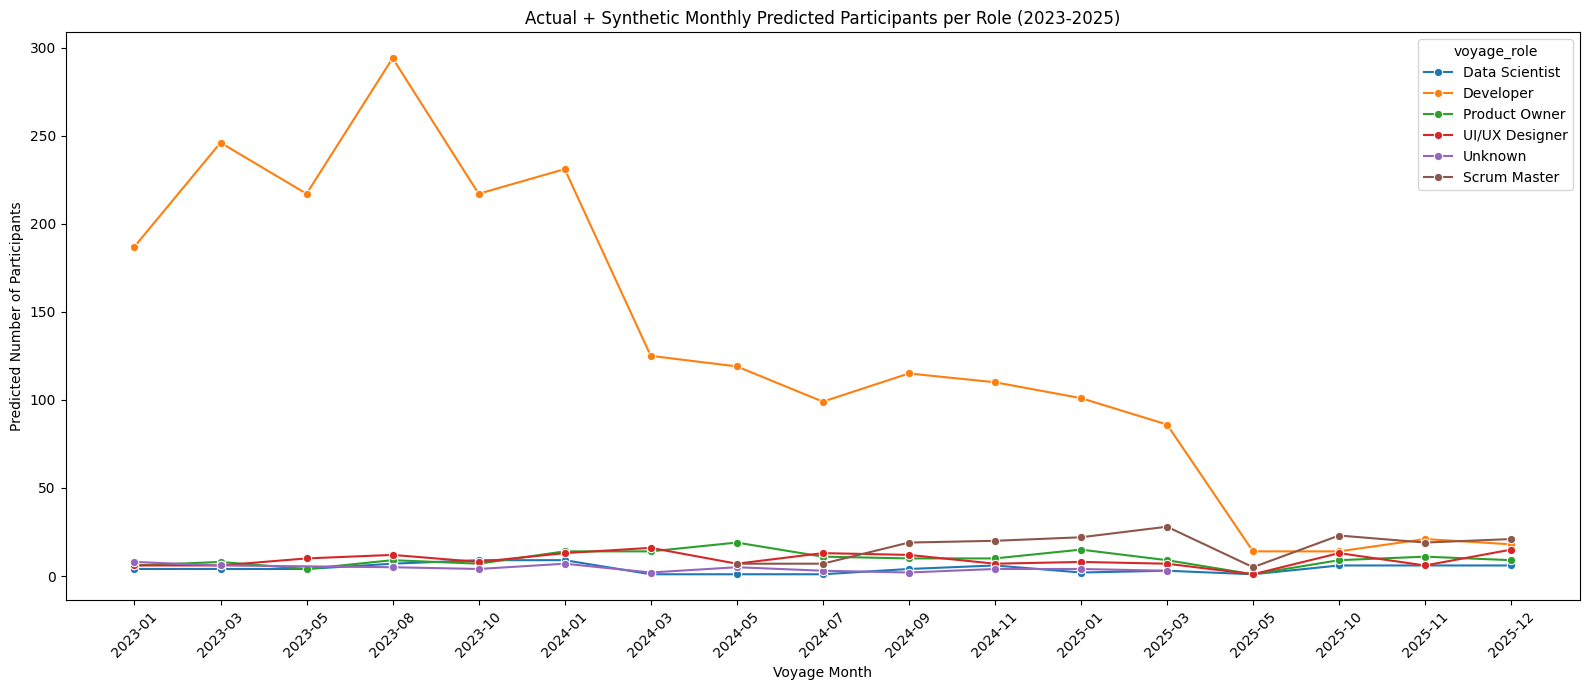

In [170]:
# Generator: Predict participants for synthetic voyage dates (excluding 'Unknown' role)
def generate_predictions_for_dates(dates, model, df_template):
    roles = df_template["voyage_role"].dropna().unique().tolist()
    roles = [role for role in roles if role != "Unknown"]
    most_common = df_template.mode().iloc[0]
    numeric_means = df_template.select_dtypes(include=[np.number]).mean()

    results = []
    for date in dates:
        for role in roles:
            synthetic_rows = pd.DataFrame([most_common.copy()] * 50)
            for col in numeric_means.index:
                synthetic_rows[col] = numeric_means[col]
            synthetic_rows["voyage_role"] = role
            synthetic_rows["updated_voyage_start_date"] = date
            synthetic_rows["subscription_status_dt"] = pd.to_datetime(date) - pd.Timedelta(days=5)

            X_synthetic = synthetic_rows.drop(columns=["has_voyage", "unique_id", "timestamp", "application_date", "voyage_from_voyage_signups", "source_other"], errors="ignore")
            y_pred = model.predict(X_synthetic)

            results.append({
                "voyage_month": pd.to_datetime(date).to_period("M"),
                "voyage_role": role,
                "predicted_participants": int(np.sum(y_pred))
            })
    return pd.DataFrame(results)

# Example usage for batch prediction
future_dates = pd.date_range("2025-10-01", "2025-12-31", freq="MS")
batch_predictions = generate_predictions_for_dates(future_dates, clf, original_df)
print("\nSynthetic predictions for future voyage months:")
print(batch_predictions)

# Combine actual and synthetic predictions
grouped_all = pd.concat([grouped_monthly, batch_predictions], ignore_index=True)
grouped_all["voyage_month"] = grouped_all["voyage_month"].astype(str)

# Plot combined predictions
plt.figure(figsize=(16, 7))
sns.lineplot(data=grouped_all, x="voyage_month", y="predicted_participants", hue="voyage_role", marker="o")
plt.title("Actual + Synthetic Monthly Predicted Participants per Role (2023-2025)")
plt.xlabel("Voyage Month")
plt.ylabel("Predicted Number of Participants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Optimal number of PCA components for 95% variance: 39


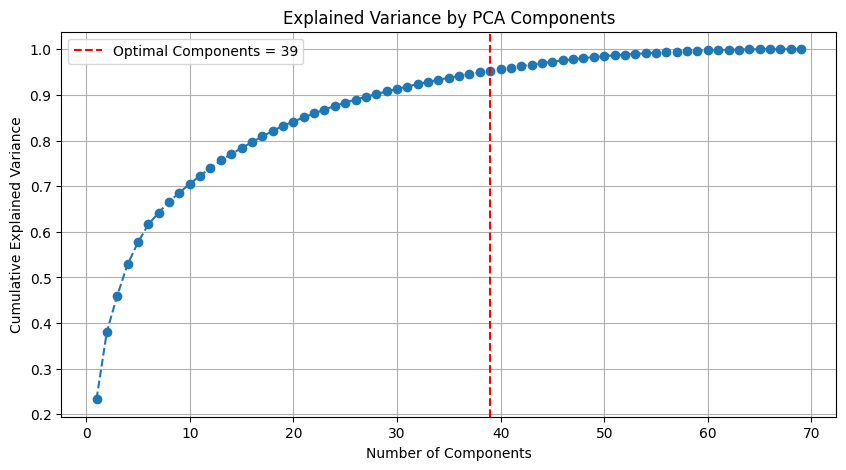


Top original features contributing to 95% PCA variance:
original_feature
source_other                  30.593772
country_code                  22.518225
country_name_from_country     20.693570
source                        20.093279
updated_voyage_number         15.019095
voyage_from_voyage_signups    14.344750
source_category               11.799315
voyage_role                    9.722840
goal                           9.122570
application_day_of_week        6.881284
gender                         4.228021
subscription_status            4.011409
no_voyages_started             3.066463
subscription_status_year       2.541963
application_week               2.202213
subscription_status_month      2.193226
application_month              2.171975
subscription_status_week       2.156629
application_age_in_days        1.870040
application_year               1.836202
Name: contribution, dtype: float64

Cross-Validation Accuracy Scores: [1.         0.99921384 1.         1.         0.99921384]

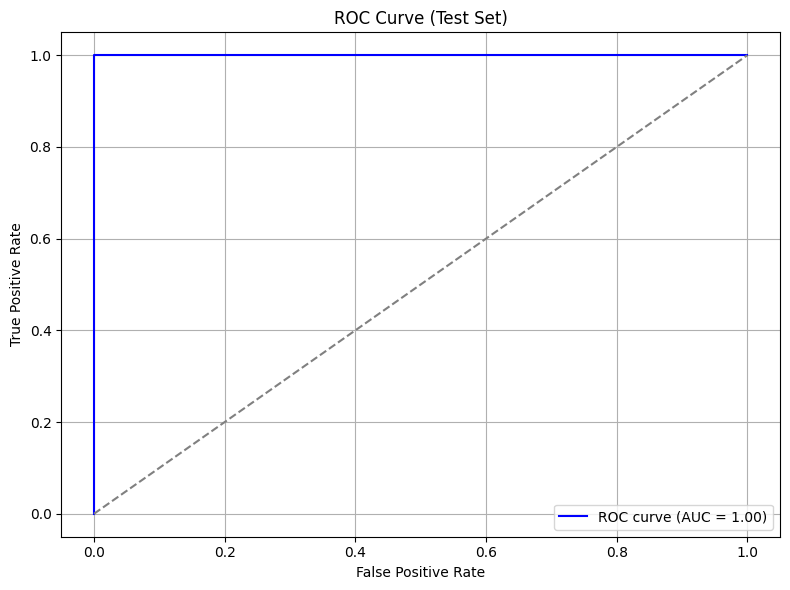

In [188]:
# Drop constant, high-null, and irrelevant columns
df = original_df.drop(columns=['unique_id'])
df = df.loc[:, df.isnull().mean() < 0.95]
df = df.loc[:, df.nunique() > 1]

# Split X and y
X = df.drop(columns=[target])
y = df[target]

# Identify column types
categorical = X.select_dtypes(include=['object']).columns.tolist()
numerical = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Imputation
X[categorical] = SimpleImputer(strategy='most_frequent').fit_transform(X[categorical])
X[numerical] = SimpleImputer(strategy='mean').fit_transform(X[numerical])

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('cat', BinaryEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numerical)
])

X_processed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

# PCA for explained variance
pca = PCA()
X_pca = pca.fit_transform(X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed)
explained_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_optimal = np.argmax(explained_variance >= 0.95) + 1
print(f"Optimal number of PCA components for 95% variance: {n_components_optimal}")

# Plot explained variance
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.axvline(n_components_optimal, color='r', linestyle='--', label=f'Optimal Components = {n_components_optimal}')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.legend()
plt.grid(True)
plt.show()

# Identify top contributing original columns
abs_loadings = np.abs(pca.components_[:n_components_optimal])
total_contributions = abs_loadings.sum(axis=0)

# Clean feature names: remove 'cat__', 'num__' and '_<digit>' suffixes
cleaned_names = pd.Series(feature_names).str.replace(r'^(cat__|num__)?(.*?)(?:_\d+)?$', r'\2', regex=True)

# Combine and rank by original column
contrib_df = pd.DataFrame({
    'original_feature': cleaned_names,
    'contribution': total_contributions
})
ranked_features = contrib_df.groupby('original_feature')['contribution'].sum().sort_values(ascending=False)

print("\nTop original features contributing to 95% PCA variance:")
print(ranked_features.head(20))

# Filter top features from encoded feature set
most_influential = ranked_features.head(20).index.tolist()
all_feature_frame = pd.DataFrame(X_processed, columns=feature_names)
selected_feature_mask = all_feature_frame.columns.to_series().apply(lambda x: any(x.startswith(f"cat__{f}") or x.startswith(f"num__{f}") for f in most_influential))
X_selected = all_feature_frame.loc[:, selected_feature_mask]

# Train/dev/test split
X_inter, X_test, y_inter, y_test = train_test_split(X_selected, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_dev, y_train, y_dev = train_test_split(X_inter, y_inter, test_size=0.25, stratify=y_inter, random_state=42)

# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# CV Evaluation
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print("\nCross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Fit and evaluate
rf_model.fit(X_train, y_train)
y_dev_pred = rf_model.predict(X_dev)
print("\nClassification Report (Dev):")
print(classification_report(y_dev, y_dev_pred))

# Test evaluation
y_test_scores = rf_model.predict_proba(X_test)[:, 1]
y_test_pred = rf_model.predict(X_test)
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()